AI Note: I used AI several times in this assignment. My main use of AI to assist with typing out long blocks of code without having to hand type everything from scratch. I made sure to leave a note with each block I used AI to assist me. 

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

penguins = pd.read_csv('C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\penguins.csv')
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


In [9]:
planets = pd.read_csv('C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\PlanetsData.csv')
planets.head(10)

,planet,distance,diameter,revolution,position
0,Mercury,36,3030,88,1
1,Venus,67,7520,225,2
2,Earth,93,7926,365,3
3,Mars,142,4217,687,4
4,Jupiter,484,88838,4332,5
5,Saturn,887,74896,10760,6
6,Uranus,1765,31762,30684,7
7,Neptune,2791,30774,60188,8
8,Pluto,3654,1428,90467,9


<Axes: xlabel='bill_depth_mm', ylabel='body_mass_g'>

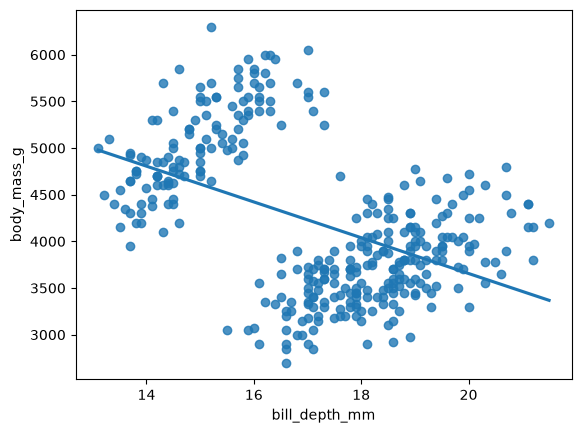

In [ ]:
#1a
sns.regplot(data=penguins, x="bill_depth_mm", y="body_mass_g", ci=None)

This scatter plot shows a negative and relavively strong relationship between bill depth and body mass in penguins. The negative direction is not what I was expecting!

In [27]:
#1b
peng_subset = penguins.dropna(subset=['bill_depth_mm', 'body_mass_g', 'flipper_length_mm', 'species'])
x = peng_subset['bill_depth_mm']
y = peng_subset['body_mass_g']

x_bar, y_bar = x.mean(), y.mean()

b1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar

print(f"manual:       b0 = {b0:.4f}, b1 = {b1:.4f}")

manual:       b0 = 7488.6524, b1 = -191.6428


This manual calculation reveals our intercept as 7488.6524 and our slope as -191.6428, giving us our estimated regression equation of y = 7488.652 - 191.6428x,

In [ ]:
#1c
Yhat = 7488.652 - 191.6428 * x
residuals = y - Yhat
rss = np.sum(residuals**2)
df = len(peng_subset) - 2
rse = np.sqrt(rss / df)
rse

np.float64(708.0771775903246)

In [15]:
r = x.corr(y)
r**2

np.float64(0.22270435351943096)

The RSE of 708.08 reveals a high approxiamate error. Our R^2 of 0.22 reveals that only 22% of variation in body mass is explained by bill depth.

In [16]:
#2a
X = sm.add_constant(peng_subset["bill_depth_mm"])

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        18:27:03   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340

Ho: Bill depth does not help predict penguin body mass. 
Ha: Bill depth helps predict penguin body mass.
Seeing the t-statistic, and all p-values being well below a significance value of 0.05, we reject the null hypothesis that bill depth does not help predict penguin body mass. 

2b

The R^2 of this model and the p-value of the slope collectively tell me that there is a significant relationship between bill depth and body mass, even if the variation in body mass isn't entirely explained by bill depth by itself. This information is consistent because a a statistical relationship can be significant even if it isn't predictively pwoerful. 

In [24]:
#2c

rng = np.random.default_rng(42)  
n_boot = 10000
n = len(peng_subset) 

xv, yv = x.to_numpy(), y.to_numpy()
boot = np.empty((n_boot, 2))

for i in range(n_boot):                  
    idx = rng.integers(0, n, n)         
    xb, yb = xv[idx], yv[idx]            
    xm, ym = xb.mean(), yb.mean()        
    slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum() 
    boot[i] = (ym - slope * xm, slope)

boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])

analytic_ci = results.conf_int()

comparison = pd.DataFrame({
    'estimate (full sample)': [b0, b1],
    'bootstrap mean':         [boot_df['b0'].mean(), boot_df['b1'].mean()],
    'CI low (formula)':       analytic_ci[0].to_numpy(),
    'CI low (bootstrap)':     [boot_df['b0'].quantile(.025), boot_df['b1'].quantile(.025)],
    'CI high (formula)':      analytic_ci[1].to_numpy(),
    'CI high (bootstrap)':    [boot_df['b0'].quantile(.975), boot_df['b1'].quantile(.975)],
}, index=['b0', 'b1'])

comparison.round(3).T

,b0,b1
estimate (full sample),7488.652,-191.643
bootstrap mean,7496.018,-192.057
CI low (formula),6829.290,-229.835
CI low (bootstrap),6959.090,-223.878
CI high (formula),8148.014,-153.450
CI high (bootstrap),8059.257,-161.913


2ca

The bootstrap gives me narrower confidence intervals. This tells me that the bootstrap tests at a slightly lower confidence level. 

2cb

The formula-based interval makes the assumption that all errors is normal and uncorrelated.

2cd

At B = 10, the confidence intervals are larger than they were at B = 10000. As we increase B, the confidence interval decreases. This tells me that bootstrapping won't make as strong of a conclusion with less repititions, therefore, there's less confidence.

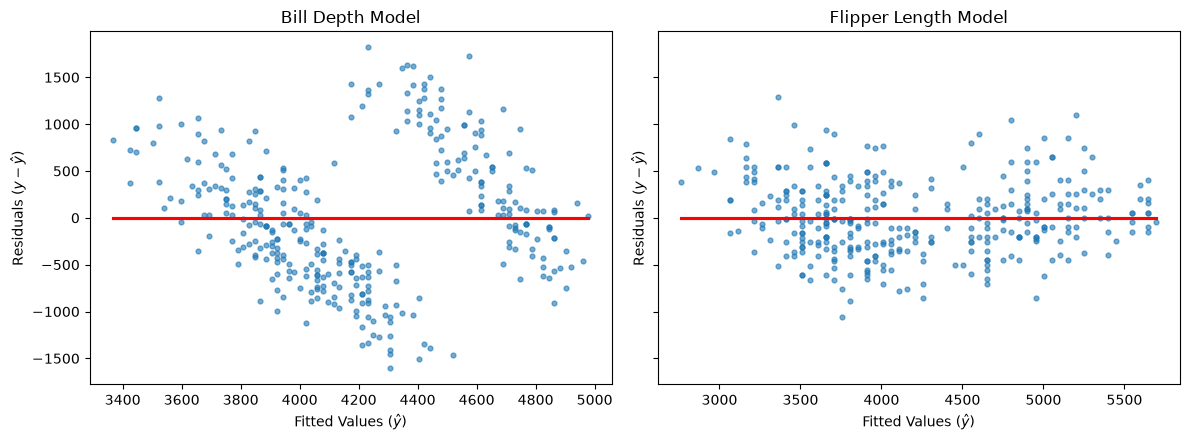

In [29]:
#3a. AI: I had Gen AI apply our class code to 3a.
def fit_penguin_model(df, x_var, y_var="body_mass_g"):
  X = sm.add_constant(df[x_var])
  return sm.OLS(df[y_var], X).fit()

def add_to_df(df, model):
  out = df.copy()
  out["fitted"] = model.fittedvalues
  out["residuals"] = model.resid
  return out

model_bill = fit_penguin_model(peng_subset, "bill_depth_mm")
model_flipper = fit_penguin_model(peng_subset, "flipper_length_mm")

peng_bill = add_to_df(peng_subset, model_bill)
peng_flipper = add_to_df(peng_subset, model_flipper)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

models_data = [
    ("Bill Depth Model", peng_bill),
    ("Flipper Length Model", peng_flipper),
]

for ax, (title, df) in zip(axes, models_data):
  sns.regplot(
      data=df,
      x="fitted",
      y="residuals",
      ci=None,
      ax=ax,
      scatter_kws={"s": 12, "alpha": 0.6},
      line_kws={"color": "red"},
  )
  ax.set_title(title)
  ax.set_xlabel("Fitted Values ($\hat{y}$)")
  ax.set_ylabel("Residuals ($y - \hat{y}$)")

plt.tight_layout()
plt.show()

These plots are telling me that there's a significant amount of variance in the bill depth model, while the flipper length model is a bit more homogenous. 

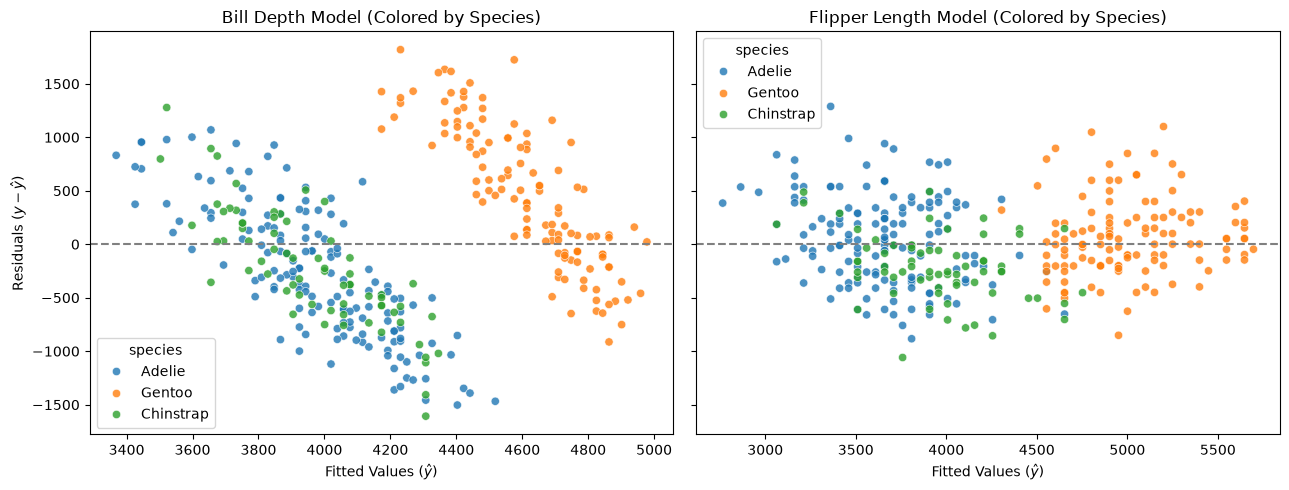

In [31]:
#3b
model_bill = fit_penguin_model(peng_subset, "bill_depth_mm")
model_flipper = fit_penguin_model(peng_subset, "flipper_length_mm")

peng_bill_df = add_to_df(peng_subset, model_bill)
peng_flipper_df = add_to_df(peng_subset, model_flipper)

# 3. Create side-by-side scatter plots colored by species
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

models = [
    ("Bill Depth Model", peng_bill_df),
    ("Flipper Length Model", peng_flipper_df),
]

for ax, (title, df) in zip(axes, models):
  sns.scatterplot(
      data=df,
      x="fitted",
      y="residuals",
      hue="species",
      alpha=0.8,
      ax=ax,
  )
  # Add horizontal reference line at y = 0
  ax.axhline(0, color="gray", linestyle="--")

  ax.set_title(f"{title} (Colored by Species)")
  ax.set_xlabel("Fitted Values ($\hat{y}$)")
  ax.set_ylabel("Residuals ($y - \hat{y}$)")

plt.tight_layout()
plt.show()

From both residual plots, I'm seeing a vast difference between the Gentoo species and the other two species in both bill depth and flipper length. The Adelie and Chinstrap penguins seem to have very similar bill depths and the Chinstrap penguins are showing to have slightly longer flippers, but this difference pales in comparison to that between the Adelie + Chinstrap and the Gentoo species. 

In [ ]:
#3ca
peng_subset[["bill_depth_mm", "body_mass_g"]].corr()

,bill_depth_mm,body_mass_g
bill_depth_mm,1.000000,-0.471916
body_mass_g,-0.471916,1.000000


In [35]:
#3cb
peng_subset.groupby('species')[["bill_depth_mm", "body_mass_g"]].corr()

bill_depth_mm  body_mass_g
species                                            
Adelie    bill_depth_mm       1.000000     0.576138
          body_mass_g         0.576138     1.000000
Chinstrap bill_depth_mm       1.000000     0.604498
          body_mass_g         0.604498     1.000000
Gentoo    bill_depth_mm       1.000000     0.719085
          body_mass_g         0.719085     1.000000

3cc

This is actually very interesting. The correlation in general is strongly negative, but each individual correlation is strongly positive. I believe this is due to the large difference between the Gentoo species and the other two species. 

Slope (beta_1): 217.1516
Intercept (beta_0): -283.2787


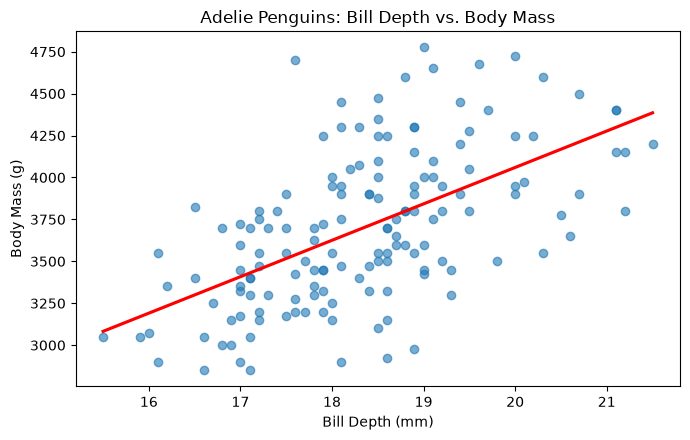

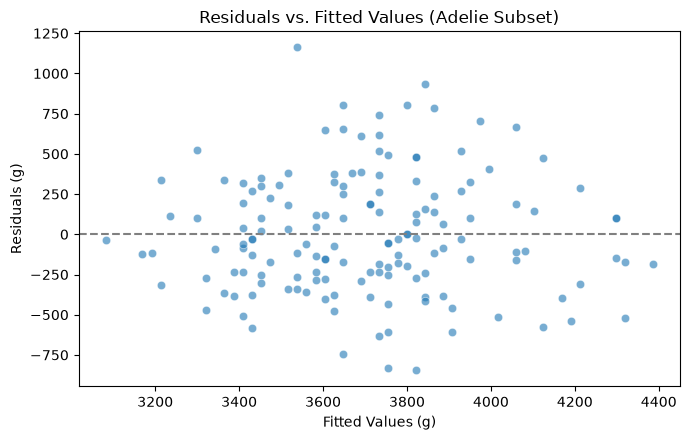

In [37]:
#3d. AI: I had help from AI with adjusting class code.

from sklearn.linear_model import LinearRegression

adelie_df = peng_subset[peng_subset['species'] == 'Adelie'].dropna(
    subset=['bill_depth_mm', 'body_mass_g']
).copy()

X = adelie_df[['bill_depth_mm']]  
y = adelie_df['body_mass_g']      

model = LinearRegression().fit(X, y)

adelie_df['y_hat'] = model.predict(X)
adelie_df['residuals'] = y - adelie_df['y_hat']

print(f"Slope (beta_1): {model.coef_[0]:.4f}")
print(f"Intercept (beta_0): {model.intercept_:.4f}")

plt.figure(figsize=(7, 4.5))
sns.regplot(
    data=adelie_df,
    x="bill_depth_mm",
    y="body_mass_g",
    ci=None,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title("Adelie Penguins: Bill Depth vs. Body Mass")
plt.xlabel("Bill Depth (mm)")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
ax = sns.scatterplot(data=adelie_df, x="y_hat", y="residuals", alpha=0.6)
ax.axhline(0, color="gray", ls="--")
ax.set_title("Residuals vs. Fitted Values (Adelie Subset)")
ax.set_xlabel("Fitted Values (g)")
ax.set_ylabel("Residuals (g)")
plt.tight_layout()
plt.show()

Amongst the Adelie species, I'm seeing a positive and relatively strong relationship between bill depth and body mass. This helps confirm my conclusion on all penguins that each species has a positive relationship between bill depth and body mass.

4a

The R^2 and R^2adj behave differently because R^2adj won't grow as quickly when more predictors are added. When predictors are added, R^2 will naturally grow to accomodate the variance accounted for. R^2adj was created to properly explain the variance covered by a model without growing too much.

In [ ]:
#4b
from sklearn.linear_model import LinearRegression

X1 = peng_subset[['flipper_length_mm']]
y = peng_subset['body_mass_g']

model1 = LinearRegression().fit(X1, y)
print(f"Model 1 (Flipper Length) R^2: {model1.score(X1, y):.4f}")

X2 = peng_subset[['flipper_length_mm', 'bill_depth_mm']]

model2 = LinearRegression().fit(X2, y)
print(f"Model 2 (+ Bill Depth)    R^2: {model2.score(X2, y):.4f}")

X3 = peng_subset[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']]

model3 = LinearRegression().fit(X3, y)
print(f"Model 3 (+ Bill Length)   R^2: {model3.score(X3, y):.4f}")

Model 1 (Flipper Length) R^2: 0.7590
Model 2 (+ Bill Depth)    R^2: 0.7610
Model 3 (+ Bill Length)   R^2: 0.7615


In [ ]:
#4bd. AI: I used AI to help adapt class code and to write out the models for me.
import statsmodels.formula.api as smf

m1 = smf.ols("body_mass_g ~ flipper_length_mm", data=peng_subset).fit()
m2 = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm", data=peng_subset).fit()
m3 = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm", data=peng_subset
).fit()

summary = pd.DataFrame({
    model_name: {
        "R^2": m.rsquared,
        "R^2_adj": m.rsquared_adj,
        "RSE": np.sqrt(m.scale),  
        "F-stat": m.fvalue,
    }
    for model_name, m in [
        ("Model 1 (1 Var)", m1),
        ("Model 2 (2 Vars)", m2),
        ("Model 3 (3 Vars)", m3),
    ]
})

summary.round(4)

,Model 1 (1 Var),Model 2 (2 Vars),Model 3 (3 Vars)
R^2,0.7590,0.7610,0.7615
R^2_adj,0.7583,0.7596,0.7594
RSE,394.2782,393.1784,393.4048
F-stat,1070.7446,539.8239,359.6718


With the F-statistic decreasing with every new predictor added, I've chosen the first model. The complexity added is unnecessary as shown by the RSE, R^2, and R^2adj not changing much for every added predictor. 

In [45]:
#4c
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     539.8
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          4.23e-106
Time:                        22:07:45   Log-Likelihood:                -2527.0
No. Observations:                 342   AIC:                             5060.
Df Residuals:                     339   BIC:                             5071.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6541.9075    540.751    -12.098      0.000   -7605.557   -5478.258
flipper_length_mm    51.5414      1.865     27.635      0.000      47.873      55.210
bill_depth_mm        22.6341     13.280      1.704      0.089      -3.488      48.756
==============================================================================
Omnibus:                        5.490   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.064   Jarque-Bera (JB):                5.361
Skew:                           0.305   Prob(JB):                       0.0685
Kurtosis:                       3.067   Cond. No.                     5.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The coefficient is 22.63, which means that you'd multiply the bill depth by this number to help predict a penguin's body mass. Obviously, B2 is now positive when it was negative in part 1. I believe this is due to the addition of another predictor in the model when the predictors all independently have positive relationships.

4d

Ho: Flipper_length_mm, bill_depth_mm, and bill_length_mm do not collectively predict the body mass of a penguin.
Ha: Between flipper_length_mm, bill_depth_mm, and bill_length_mm, at least one predictor can help predict the body mass of a penguin.

With a F-statistic of 359.67, I can safely reject the null hypothesis and confirm that at least one of the above predictors is a valid predictor of penguin body mass.

In [47]:
#5a
import statsmodels.formula.api as smf

mod = smf.ols("revolution ~ distance", data=planets).fit()
mod.rsquared

np.float64(0.9780632018272492)

Judging from R^2 alone, this looks to be a great model. 97.8% of a planet's revolution can be predicted by distance.

In [57]:
planets['revolution_predicted'] = mod.fittedvalues
mod.fittedvalues

0    -3711.348645
1    -2964.382280
2    -2337.894361
3    -1157.205590
4     7083.520113
5    16794.082858
6    37950.097969
7    62672.275081
8    83466.854854
dtype: float64

I'm seeing that the four closest planets have negative revolutions due to their close distance to the sun comapared to the outer gas giants. This tells me that the line of fit isn't such a great predictor for individual planets even if it's a great overall fit. 

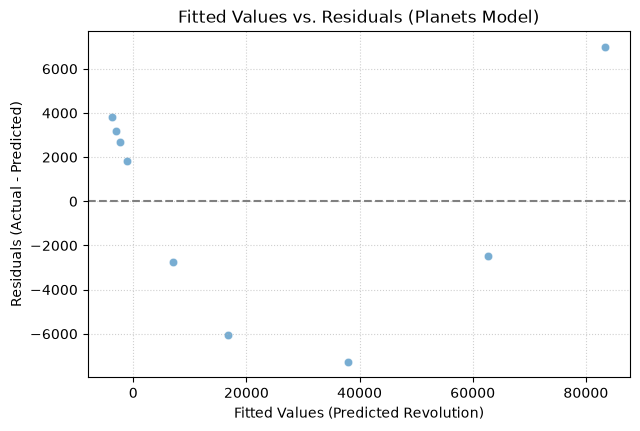

In [ ]:
fitted = mod.fittedvalues
residuals = mod.resid
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color="gray", ls="--")
plt.xlabel("Fitted Values (Predicted Revolution)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Fitted Values vs. Residuals (Planets Model)")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

From the plot, I'm seeing that a linear model is not a good way to predict non-linear curves. This model is not a valid predictor!

In [59]:
#5ca
planets["distancelog"] = np.log(planets["distance"])
planets["revolutionlog"] = np.log(planets["revolution"])
modlog = smf.ols("revolutionlog ~ distancelog", data=planets).fit()
modlog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          revolutionlog   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        23:34:48   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.9031      0.007   -122.147      0.000      -0.921      -0.886
distancelog     1.5013      0.001   1259.092      0.000       1.498       1.504
==============================================================================
Omnibus:                        4.152   Durbin-Watson:                   2.345
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                1.862
Skew:                           1.112   Prob(JB):                        0.394
Kurtosis:                       2.882   Cond. No.                         24.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

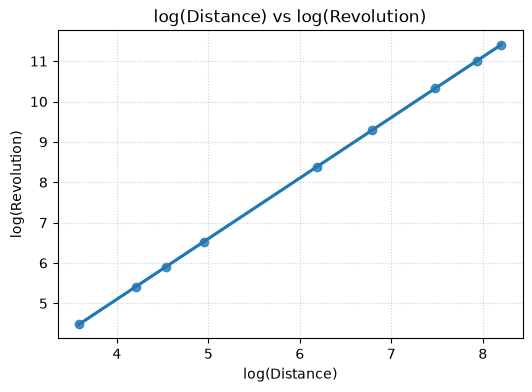

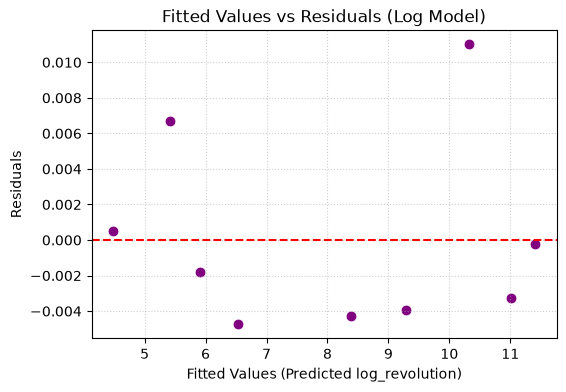

In [60]:
#5cb. AI: I used AI to adjust with the class code. 
log_fitted = modlog.fittedvalues
log_residuals = modlog.resid

plt.figure(figsize=(6, 4))
sns.regplot(x="distancelog",y="revolutionlog",data=planets,ci=None)
plt.title("log(Distance) vs log(Revolution)")
plt.xlabel("log(Distance)")
plt.ylabel("log(Revolution)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=log_fitted, y=log_residuals, color="purple", s=60)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("Fitted Values vs Residuals (Log Model)")
plt.xlabel("Fitted Values (Predicted log_revolution)")
plt.ylabel("Residuals")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

The log model is a better fit. The fitted values all have smaller residuals from the line of fit and there isn't a very obvious curve in the data points. 

The new R^2 is 1.000 and the coefficient is 1.5013 or 3/2. 
Revlution^2 = Distance^3
Revlution^2 = (Distance^3/2)^3
Revolution = Distance^3/2

In [62]:
#5cd
planets["revolutionlog_fitted"] = np.exp(modlog.fittedvalues)
planets[["planet", "revolution", "revolution_predicted", "revolutionlog_fitted"]]

,planet,revolution,revolution_predicted,revolutionlog_fitted
0,Mercury,88,-3711.348645,87.955672
1,Venus,225,-2964.382280,223.498426
2,Earth,365,-2337.894361,365.655904
3,Mars,687,-1157.205590,690.272590
4,Jupiter,4332,7083.520113,4350.622150
5,Saturn,10760,16794.082858,10802.199220
6,Uranus,30684,37950.097969,30348.267640
7,Neptune,60188,62672.275081,60383.237531
8,Pluto,90467,83466.854854,90486.168764


The new model is significantly closer to to reality than the initial predicted model. This is a huge improvement over the first model. 